In [ ]:
import librosa
import librosa.display
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
audio_file = "../audio/reverb_ir.wav"

In [3]:
ipd.Audio(audio_file)

In [6]:
audio, sr = librosa.load(audio_file)
audio, sr

(array([ 0.0001351 , -0.00014357,  0.00022879, ...,  0.        ,
         0.        ,  0.        ], shape=(54030,), dtype=float32),
 22050)

In [7]:
audio.size

54030

In [8]:
# duration of 1 sample
sample_duration = 1 / sr
print(f"{sample_duration:.6f}")

0.000045


In [9]:
# duration of the audio signal in seconds
duration = sample_duration * len(audio)
print(f"{duration:.6f}")

2.450340


(-1.0, 1.0)

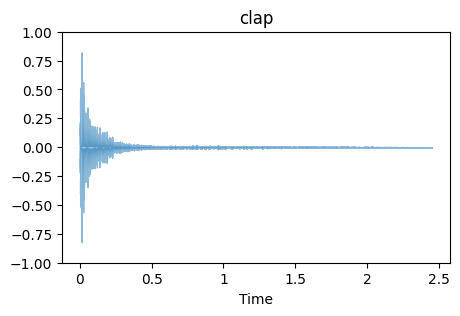

In [19]:
# visualize the waveforms
plt.figure(figsize=(5, 3))
librosa.display.waveshow(audio, alpha=0.5)
plt.title("clap")
plt.ylim((-1, 1))

In [29]:
FRAME_SIZE=1024
HOP_LENGTH=512

# calculate the amplitude envelope
def amplitude_envelope(signal, frame_size, hop_length):
    amplitude_envelope = []
    
    # calculaate AE(max value) for each frame
    for i in range(0, len(signal), hop_length):
        current_frame_amplitude_envelope = max(signal[i: i+frame_size])
        amplitude_envelope.append(current_frame_amplitude_envelope)
    
    return np.array(amplitude_envelope)

def fancy_amplitude_envelope(signal, frame_size, hop_length):
    return np.array([max(signal[i:i+frame_size]) for i in range(0, signal.size, hop_length)])

In [30]:
ae_audio = amplitude_envelope(audio, FRAME_SIZE, HOP_LENGTH)
len(ae_audio)

106

In [31]:
fancy_ae_audio = fancy_amplitude_envelope(audio, FRAME_SIZE, HOP_LENGTH)
len(fancy_ae_audio)

106

(-1.0, 1.0)

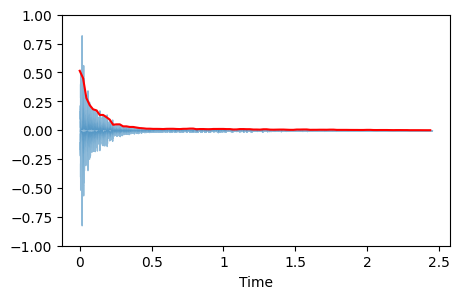

In [33]:
frames = range(0, ae_audio.size)
t = librosa.frames_to_time(frames, hop_length=HOP_LENGTH)

plt.figure(figsize=(5, 3))
librosa.display.waveshow(audio, alpha=0.5)
plt.plot(t, ae_audio, color="r")
plt.ylim((-1, 1))
